# PSFFieldEPSF visualisation

Visual + quantitative check on the production PSF model. Section ordering matters: **the star sanity check comes first** — if the build pipeline isn't actually selecting stars, every downstream PSF metric is meaningless no matter how it's computed.

Sections:

1. Sanity check — same source across all bands (is the build picking real isolated point sources?).
2. Load PSFFieldEPSF — per-band core σ table.
3. Per-band reconstructed PSF at field centre (log scale, core σ in title).
4. Radial profile per band.
5. Held-out validation — Pearson r and chi^2/dof per band.


In [24]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "io" else Path.cwd()
sys.path.insert(0, str(ROOT / "models"))

from psf.psf_field_pca import ALL_BANDS as PCA_BANDS

TRAIN_DIR = ROOT / "data/psf_training_gaia"
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in PCA_BANDS}


## 1. Sanity check — same source across all bands (GAIA-anchored)

Stamps are now built from **GAIA DR3 stars** (sub-mas RA/Dec, confirmed point sources via parallax / proper motion / single-source flags) instead of CenterNet detections. Each band's WCS projects (RA, Dec) → pixel coords directly, eliminating the bogus VIS-to-Rubin half-pixel scaling that caused the previous off-centre stamps.

This cell picks 10 random GAIA-anchored sources (anchored on rubin_r) and shows the matched stamp in every band where the source has coverage.

**What to look for:** clean centred star-like cores in every panel. With GAIA you should see this — if you don't, the build pipeline still has a bug.

Empty grey panels = the source isn't in that band's npz (failed SNR cut, edge clip, or no coverage). SNR labelled in red.

Build:
```
PYTHONPATH=models python models/psf/build_psf_gaia_training_set.py \
    --rubin-dir   data/rubin_tiles_all \
    --euclid-dir  data/euclid_tiles_all \
    --out-dir     data/psf_training_gaia \
    --stamp-size  32
```


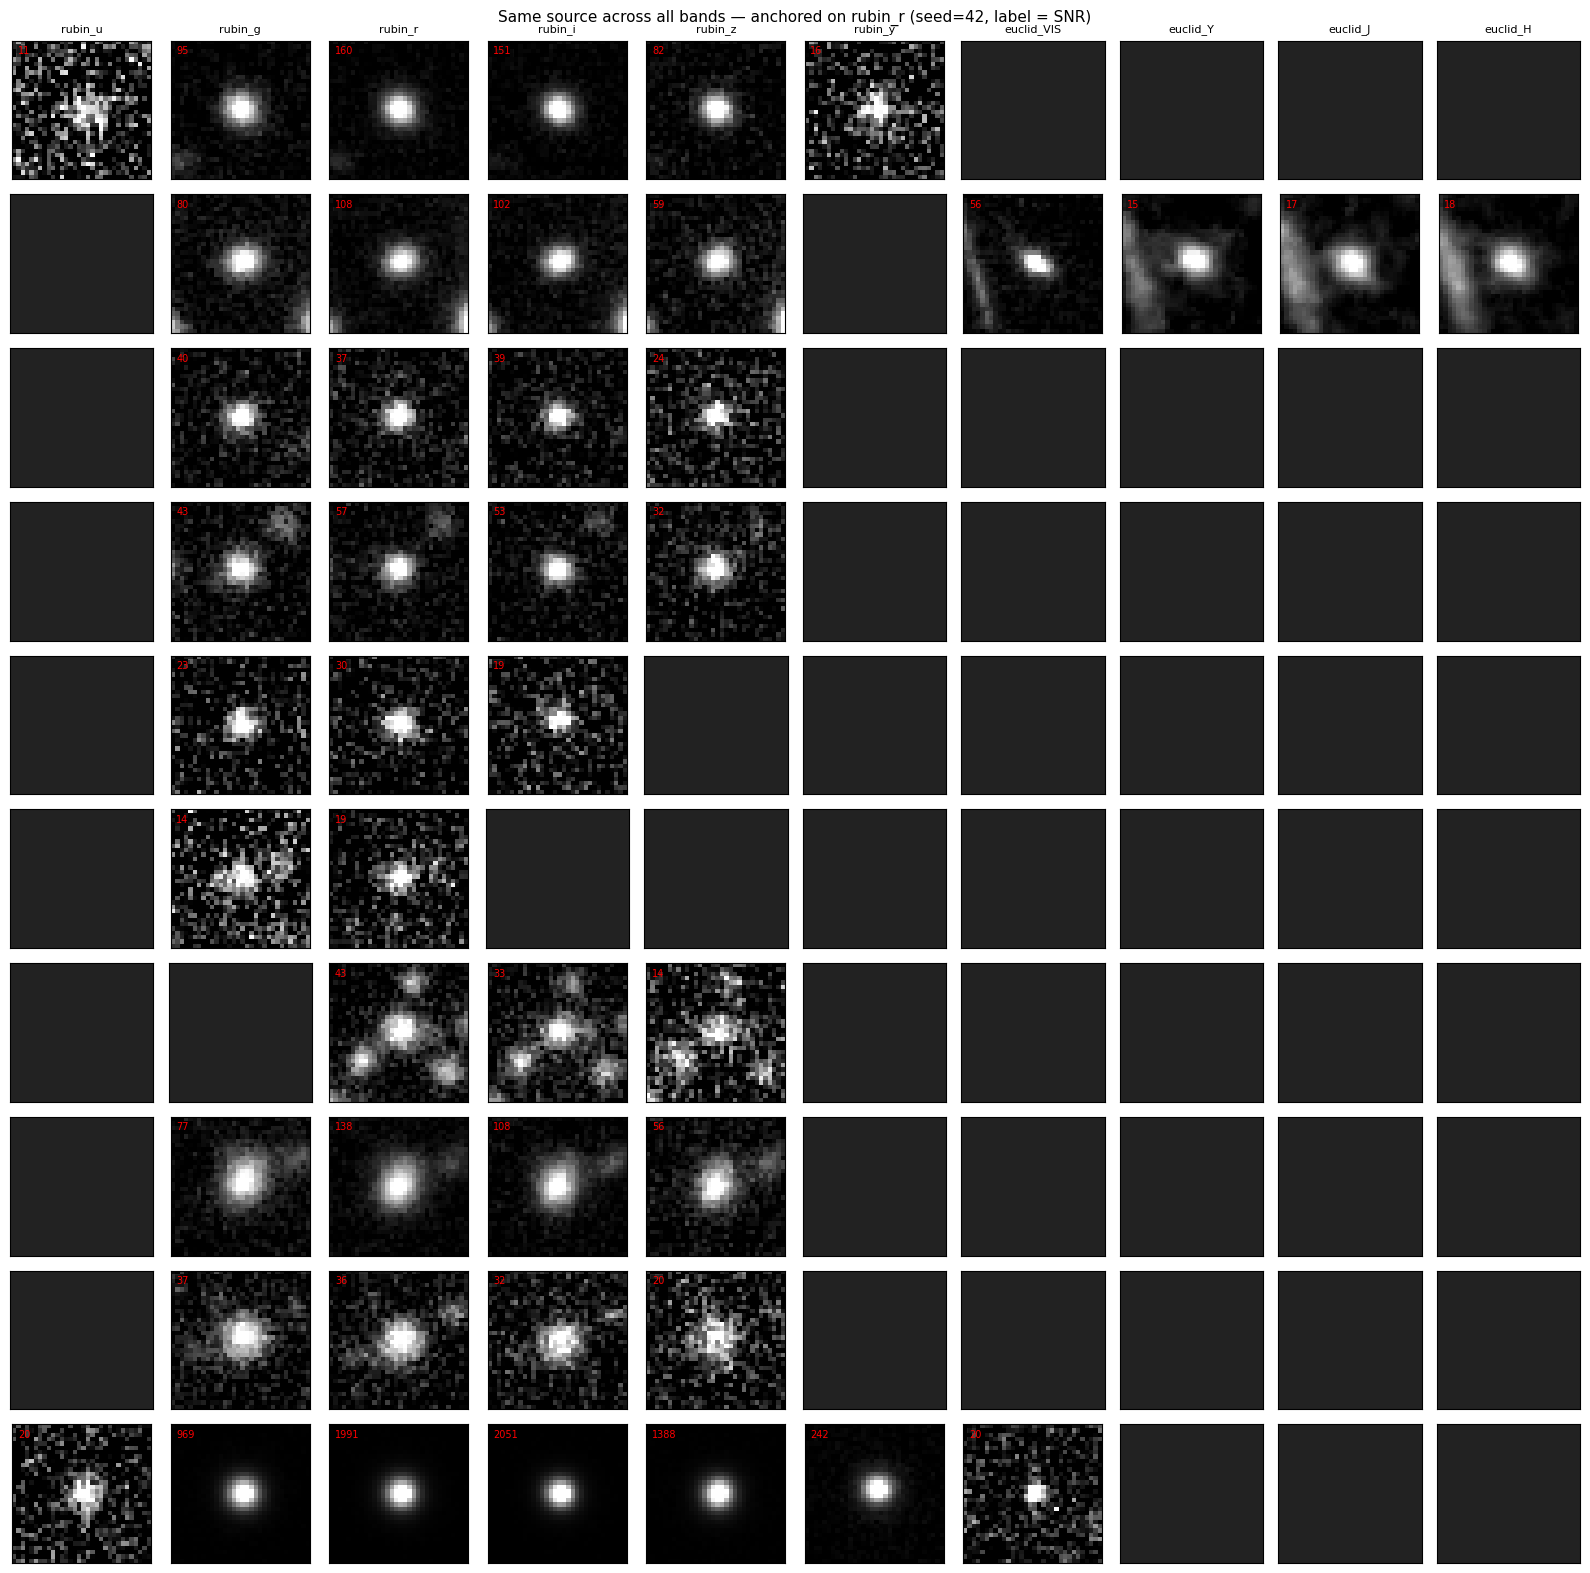

In [25]:
TRAIN_DIR = ROOT / "data/psf_training_v4"
ANCHOR_BAND = "rubin_r"
N_RANDOM = 10
SEED = 42

d_anchor = np.load(TRAIN_DIR / f"{ANCHOR_BAND}.npz", allow_pickle=False)
rng = np.random.RandomState(SEED)
anchor_idx = rng.choice(d_anchor["stamps"].shape[0], N_RANDOM, replace=False)
anchor_tiles = d_anchor["tile_id"][anchor_idx]
anchor_pos = d_anchor["pos_pix"][anchor_idx]  # rubin pixel coords (0.2"/px)

band_data = {}
for band in PCA_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    band_data[band] = np.load(p, allow_pickle=False) if p.exists() else None

fig, axes = plt.subplots(N_RANDOM, len(PCA_BANDS),
                         figsize=(len(PCA_BANDS) * 1.6, N_RANDOM * 1.6))
for row in range(N_RANDOM):
    tile = anchor_tiles[row]
    xr, yr = anchor_pos[row]
    for col, band in enumerate(PCA_BANDS):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(band, fontsize=8)
        d = band_data[band]
        if d is None:
            ax.set_facecolor("#222"); continue
        tile_match = d["tile_id"] == tile
        if not tile_match.any():
            ax.set_facecolor("#222"); continue
        # rubin_r anchor pos is in rubin (0.2"/px) frame.
        # Rubin bands: same scale (match directly).
        # Euclid bands: 0.1"/px = 2× rubin (multiply by 2).
        if band.startswith("rubin"):
            x_band, y_band, tol = xr, yr, 5.0   # 5 rubin px ≈ 1 arcsec
        else:
            x_band, y_band, tol = xr * 2.0, yr * 2.0, 10.0  # 10 vis px ≈ 1 arcsec
        cand = np.where(tile_match)[0]
        cp = d["pos_pix"][cand]
        dist = np.hypot(cp[:, 0] - x_band, cp[:, 1] - y_band)
        best = cand[np.argmin(dist)]
        if dist.min() > tol:
            ax.set_facecolor("#222"); continue
        s = d["stamps"][best]
        snr = float(d["snr"][best])
        vmax = max(float(np.nanpercentile(s, 99)), 1e-6)
        ax.imshow(s, origin="lower", cmap="gray", vmin=0.0, vmax=vmax)
        ax.text(0.04, 0.96, f"{snr:.0f}", color="red", fontsize=7,
                transform=ax.transAxes, va="top", ha="left",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1))
fig.suptitle(f"Same source across all bands — anchored on {ANCHOR_BAND} (seed={SEED}, label = SNR)",
             fontsize=11)
plt.tight_layout(); plt.show()


## 2. Load PSFFieldEPSF

Empirical ePSF per band built with photutils.EPSFBuilder. One ePSF per band, no spatial variation (PCA on the same data showed near-zero spatial R²).

Build pipeline behind the scenes:

- Centroids data-derived per stamp (intensity-weighted, brightest-pixel init + iterative refinement). Critical: the refinement starts from the stamp's brightest pixel, not the geometric centre, so it actually finds the source even if the input detection's pixel position is several pixels off.
- Post-rebuild centring check: rejects any stamp whose post-rebuild peak isn't within ±3 native px of the centre.
- Background from sigma-clipped median over wide annulus (8-14 native px), avoiding contamination from the PSF wings.
- Per-band-group SNR cuts: Rubin = 80, Euclid = 30.
- Morphology cut: σ_native ∈ [Q25 · 0.6, Q25 · 1.4].
- psf_size = 99 oversampled.

Reports **core σ** (intensity-weighted within r < 5 native px) — the meaningful metric for stellar photometry. Full-stamp σ is inflated by wing residuals.


In [26]:
from psf.psf_field_pca import PSFFieldEPSF, _core_sigma_mas, ALL_BANDS as PCA_BANDS

PCA_CKPT = ROOT / "models/checkpoints/psf_field_pca/psf_field_pca.pt"
psf_pca = PSFFieldEPSF.load(PCA_CKPT)
print(f"psf_size={psf_pca.psf_size}  oversampling={psf_pca.oversampling}")
print()
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in PCA_BANDS}
print(f"{'band':14s} {'N_train':>8s} {'core σ (mas)':>14s} {'core/total flux':>17s}")
for b in psf_pca.band_names:
    if b not in psf_pca.models: continue
    m = psf_pca.models[b]
    sig_mas, core_frac = _core_sigma_mas(m["data"], psf_pca.oversampling, b)
    print(f"{b:14s} {m['n_train']:8d} {sig_mas:>14.0f} {core_frac:>17.3f}")


psf_size=99  oversampling=5

band            N_train   core σ (mas)   core/total flux
rubin_u             535            431             0.747
rubin_g             757            401             0.817
rubin_r             757            391             0.831
rubin_i             757            379             0.853
rubin_z             757            385             0.837
rubin_y             757            395             0.822
euclid_VIS          847            122             0.957
euclid_Y            819            191             0.886
euclid_J            806            196             0.860
euclid_H            820            201             0.801


## 3. Per-band ePSF (log scale, core σ in title)

Reconstructed PSF per band. Log colormap (3 decades from peak) with noise floor clipped. Title reports core σ in mas.

Expected band σ (FWHM/2.35): Rubin ~300-400 mas, Euclid VIS ~70-150 mas, Euclid Y/J/H ~170-200 mas.


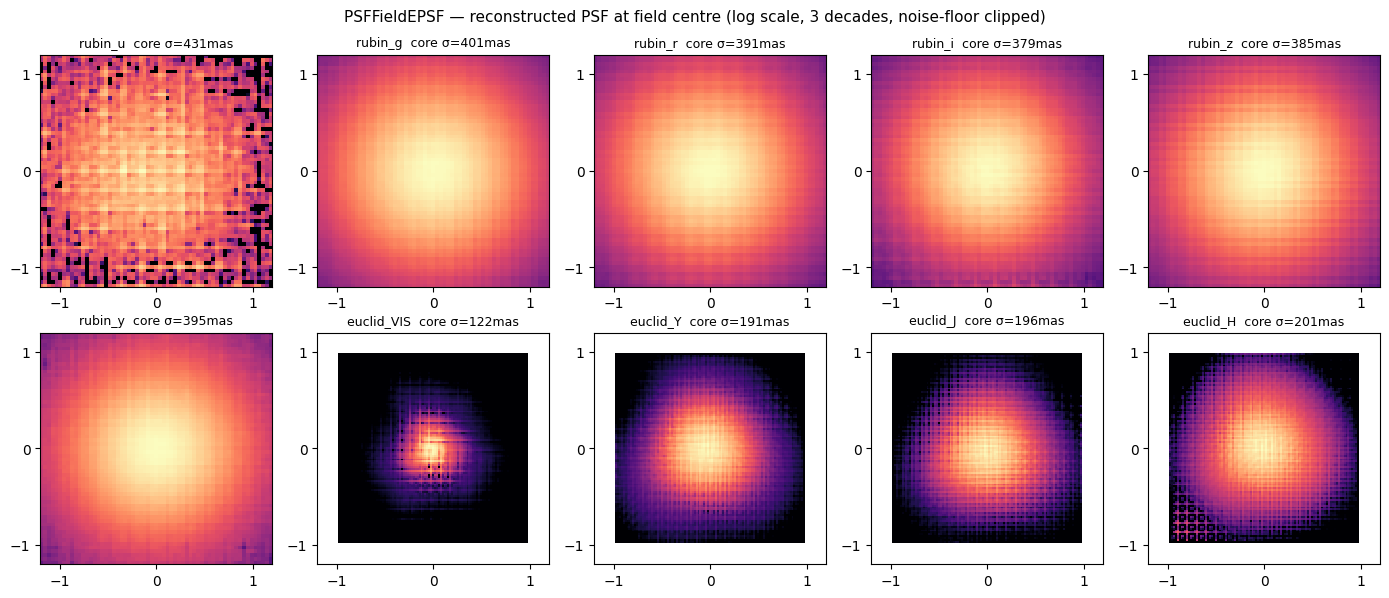

In [27]:
from matplotlib.colors import LogNorm

PCA_DISPLAY_HALF = 1.2  # arcsec axis half-extent

def pca_render(band):
    bi = PCA_BANDS.index(band)
    psf = psf_pca(torch.zeros(1, 2), torch.tensor([bi]))[0, 0].numpy()
    return psf

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, band in zip(axes.flat, PCA_BANDS):
    if band not in psf_pca.models:
        ax.set_visible(False); continue
    p = pca_render(band)
    P = p.shape[0]
    px_over = PCA_PX_NATIVE[band] / psf_pca.oversampling
    ext = (P - 1) / 2.0 * px_over
    pk = float(p.max())
    # 3-decade log scale; clip everything below vmin to vmin so the wings'
    # noise floor doesn't show up as white holes / striped grid pattern.
    vmin = max(pk * 1e-3, 1e-12)
    p_show = np.clip(p, vmin, pk)
    ax.imshow(p_show, origin="lower", cmap="magma",
              extent=[-ext, ext, -ext, ext],
              norm=LogNorm(vmin=vmin, vmax=pk),
              interpolation="nearest")
    sig_mas, core_frac = _core_sigma_mas(p, psf_pca.oversampling, band)
    ax.set_title(f"{band}  core σ={sig_mas:.0f}mas", fontsize=9)
    ax.set_xlim(-PCA_DISPLAY_HALF, PCA_DISPLAY_HALF)
    ax.set_ylim(-PCA_DISPLAY_HALF, PCA_DISPLAY_HALF)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
fig.suptitle("PSFFieldEPSF — reconstructed PSF at field centre (log scale, 3 decades, noise-floor clipped)", fontsize=11)
plt.tight_layout(); plt.show()


## 4. Radial profile per band

Azimuthal-mean radial profile (log-y). Real PSFs fall off rapidly to a noise floor; flat or rising tails at large r mean residual contamination.


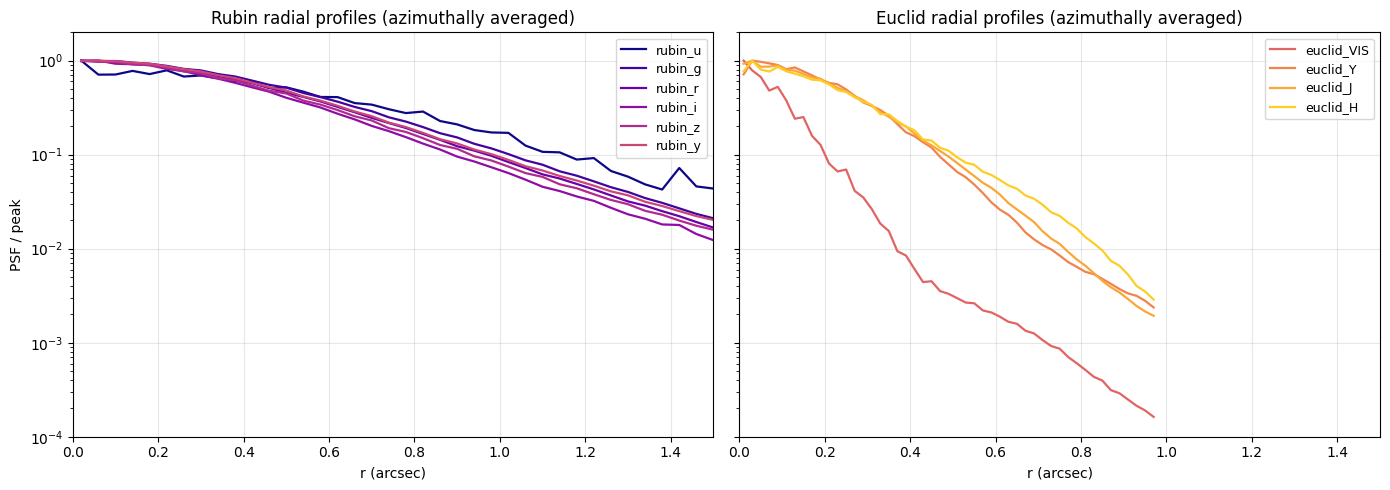

In [28]:
def radial_profile(psf, n_bins=None):
    P = psf.shape[0]
    half = (P - 1) / 2.0
    if n_bins is None:
        n_bins = max(8, int(half))
    yy, xx = np.indices(psf.shape, dtype=np.float32)
    r = np.sqrt((xx - half) ** 2 + (yy - half) ** 2)
    edges = np.linspace(0, half, n_bins + 1)
    centres, profile = [], []
    for k in range(n_bins):
        m = (r >= edges[k]) & (r < edges[k + 1])
        if m.any():
            centres.append(0.5 * (edges[k] + edges[k + 1]))
            profile.append(float(psf[m].mean()))
    return np.array(centres), np.array(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.9, len(PCA_BANDS)))
for bi, band in enumerate(PCA_BANDS):
    if band not in psf_pca.models:
        continue
    psf = psf_pca(torch.zeros(1, 2), torch.tensor([bi]))[0, 0].numpy()
    r_ovs, prof = radial_profile(psf)
    px_arcsec = (PCA_PX_NATIVE[band] / psf_pca.oversampling)  # arcsec per oversampled px
    r_arcsec = r_ovs * px_arcsec
    prof_norm = prof / max(prof.max(), 1e-12)
    ax = axes[0 if band.startswith("rubin") else 1]
    ax.plot(r_arcsec, prof_norm, color=colors[bi], lw=1.6, label=band)
for ax, title in zip(axes, ["Rubin", "Euclid"]):
    ax.set_yscale("log")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(1e-4, 2)
    ax.set_xlabel("r (arcsec)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f"{title} radial profiles (azimuthally averaged)")
axes[0].set_ylabel("PSF / peak")
plt.tight_layout(); plt.show()


## 5. Held-out validation — shape match per band

Pearson r and chi^2/dof for the model rendered at the top-5 SNR held-out stars per band. Pearson r is the meaningful comparison number across bands (normalised, shape-only). chi^2/dof grows with stamp brightness — compare *across bands* rather than to 1.


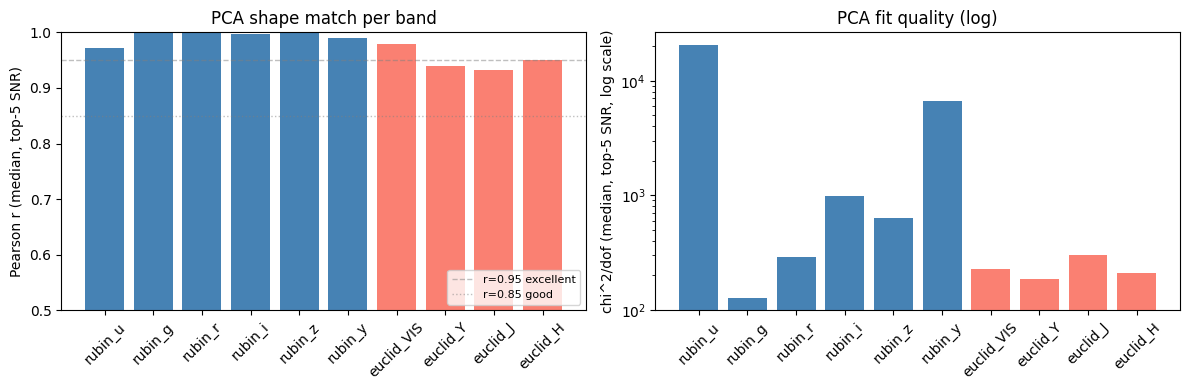


band            N_train    EVR0        r     chi2/dof


KeyError: 'explained_variance_ratio'

In [29]:
TRAIN_DIR_PCA = ROOT / 'data/psf_training_v4'

def _chi2(pred, obs, rms):
    inv_var = 1.0 / np.maximum(rms, 1e-6) ** 2
    return float(((pred - obs) ** 2 * inv_var).sum()) / max(int(obs.size - 1), 1)

def _pearson(a, b):
    a = a.ravel().astype(np.float64); b = b.ravel().astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    den = np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())
    return float((a*b).sum() / max(den, 1e-12))

results = {}
for band in PCA_BANDS:
    if band not in psf_pca.models: continue
    path = TRAIN_DIR_PCA / f'{band}.npz'
    if not path.exists(): continue
    d = np.load(path, allow_pickle=False)
    if d['stamps'].shape[0] < 5: continue
    order = np.argsort(d['snr'])[::-1][:5]
    stamps = torch.tensor(d['stamps'][order], dtype=torch.float32)
    rms    = torch.tensor(d['rms'][order],    dtype=torch.float32)
    frac   = torch.tensor(d['frac_xy'][order], dtype=torch.float32)
    pos    = torch.tensor(d['pos_norm'][order], dtype=torch.float32)
    bidx   = torch.full((5,), PCA_BANDS.index(band), dtype=torch.long)
    psf_o = psf_pca(pos, bidx)
    rendered = psf_pca.render_at_native(psf_o, frac, stamp_size=stamps.shape[-1])
    pred = rendered.squeeze(1)
    inv_var = 1.0 / rms.clamp(min=1e-6) ** 2
    num = (pred * stamps * inv_var).sum(dim=(-2,-1))
    den = (pred * pred * inv_var).sum(dim=(-2,-1)).clamp(min=1e-12)
    alpha = num / den
    scaled = alpha.view(-1,1,1) * pred
    chi2s = [_chi2(scaled[k].numpy(), stamps[k].numpy(), rms[k].numpy()) for k in range(5)]
    rs    = [_pearson(scaled[k].numpy(), stamps[k].numpy()) for k in range(5)]
    results[band] = (float(np.median(chi2s)), float(np.median(rs)))

bands_ok  = list(results.keys())
chi2_vals = [results[b][0] for b in bands_ok]
r_vals    = [results[b][1] for b in bands_ok]
colors    = ['steelblue' if b.startswith('rubin') else 'salmon' for b in bands_ok]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bands_ok, r_vals, color=colors)
axes[0].set_ylabel('Pearson r (median, top-5 SNR)')
axes[0].set_title('PCA shape match per band')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.95, color='gray', ls='--', lw=1, alpha=0.5, label='r=0.95 excellent')
axes[0].axhline(0.85, color='gray', ls=':',  lw=1, alpha=0.5, label='r=0.85 good')
axes[0].legend(fontsize=8, loc='lower right')
axes[1].bar(bands_ok, chi2_vals, color=colors)
axes[1].set_yscale('log')
axes[1].set_ylabel('chi^2/dof (median, top-5 SNR, log scale)')
axes[1].set_title('PCA fit quality (log)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print()
print(f'{"band":14s} {"N_train":>8s}  {"EVR0":>6s}   {"r":>6s}   {"chi2/dof":>10s}')
for band in bands_ok:
    chi2_v, r_v = results[band]
    m = psf_pca.models[band]
    print(f'{band:14s} {m["n_train"]:8d}  {m["explained_variance_ratio"][0]:.3f}   '
          f'{r_v:.3f}   {chi2_v:>10.1f}')
